<a href="https://colab.research.google.com/github/Haniya-Imran/ML-Algorithms-Projects/blob/main/Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Students Performance Dataset Analysis**

# **Project Overview:**
This project focuses on analyzing student performance data to understand influencing factors and predict academic outcomes. It includes data cleaning, exploratory analysis, and machine learning model development.

## **Contents:**
* Import Libraries
* Load Dataset
* Dataset Overview
* Exploratory Data Analysis (EDA)
* Data Preprocessing
* Feature Scaling
* Train-Test Split
* Model Training
* Model Evaluation
* Hyperparameter Tuning
* Pipeline
* Feature Importance
* Final Result
* Conclusion

### **Import Libraries:**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

### **Dataset Load:**

In [ ]:
df = pd.read_csv('/content/StudentsPerformance.csv')

### **Dataset Overview:**

In [ ]:
display(df.head())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
display(df.tail())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [ ]:
display(df.shape)

(1000, 8)

In [ ]:
display(df.columns)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
display(df.describe())

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
display(df.dtypes)

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [ ]:
display(df.isnull().sum())

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
display(df.duplicated().sum())

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)
display(df.shape)

(1000, 8)

### **Data Cleaning:**

In [ ]:
numerical_cols = ['math score', 'reading score', 'writing score']
numerical_df = df[numerical_cols]

Q1 = numerical_df.quantile(0.25)
Q3 = numerical_df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count_per_column = ((numerical_df < lower_bound) | (numerical_df > upper_bound)).sum()

display(outliers_count_per_column)

,0
math score,8
reading score,6
writing score,5


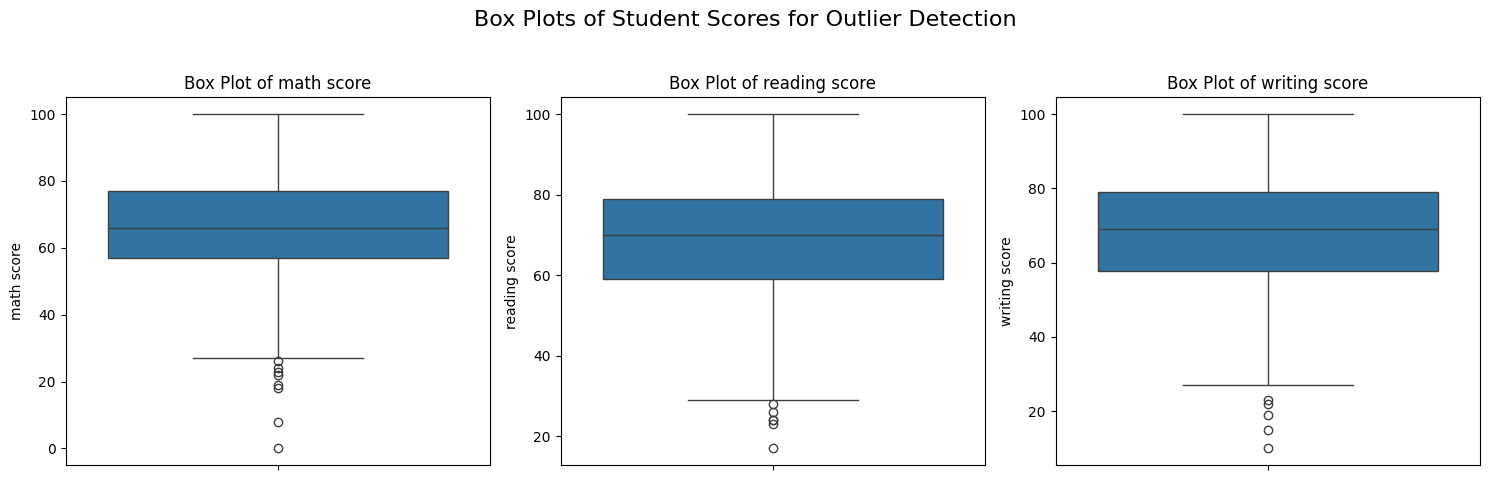

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(1, len(numerical_cols),figsize=(15, 5), squeeze=False); fig.suptitle('Box Plots of Student Scores for Outlier Detection', fontsize=16)
for i, col in enumerate(numerical_cols): sns.boxplot(y=df[col], ax=axes[0, i]); axes[0, i].set_title(f'Box Plot of {col}')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

Box plots show the distribution of scores and indicate the presence of outliers.

In [ ]:
# Outlier Handling (Capping)
numerical_cols = df.select_dtypes(include=np.number).columns
Q1, Q3 = df[numerical_cols].quantile(0.25), df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
for col in numerical_cols: df[col] = df[col].clip(lower=lower_bound[col], upper=upper_bound[col])

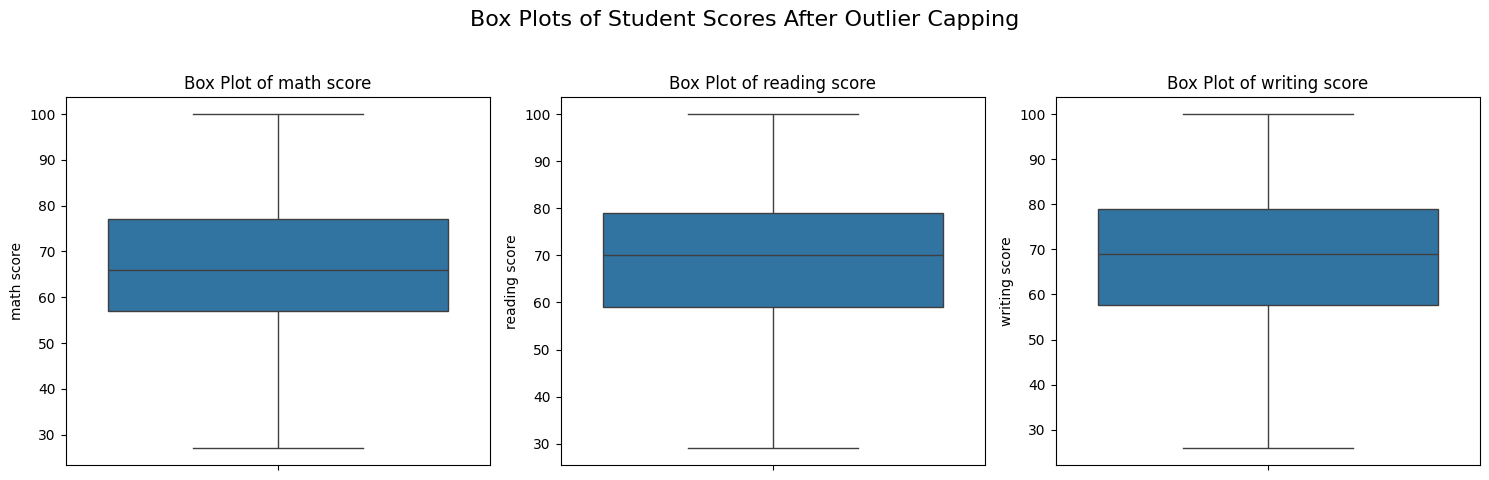

In [ ]:
# After outlier handling, display new boxplots for verification
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(15, 5), squeeze=False)
fig.suptitle('Box Plots of Student Scores After Outlier Capping', fontsize=16)
for i, col in enumerate(numerical_cols): sns.boxplot(y=df[col], ax=axes[0, i]); axes[0, i].set_title(f'Box Plot of {col}')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

These box plots confirm that outliers have been effectively capped.

### **Exploratory Data Analysis:**

In [ ]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

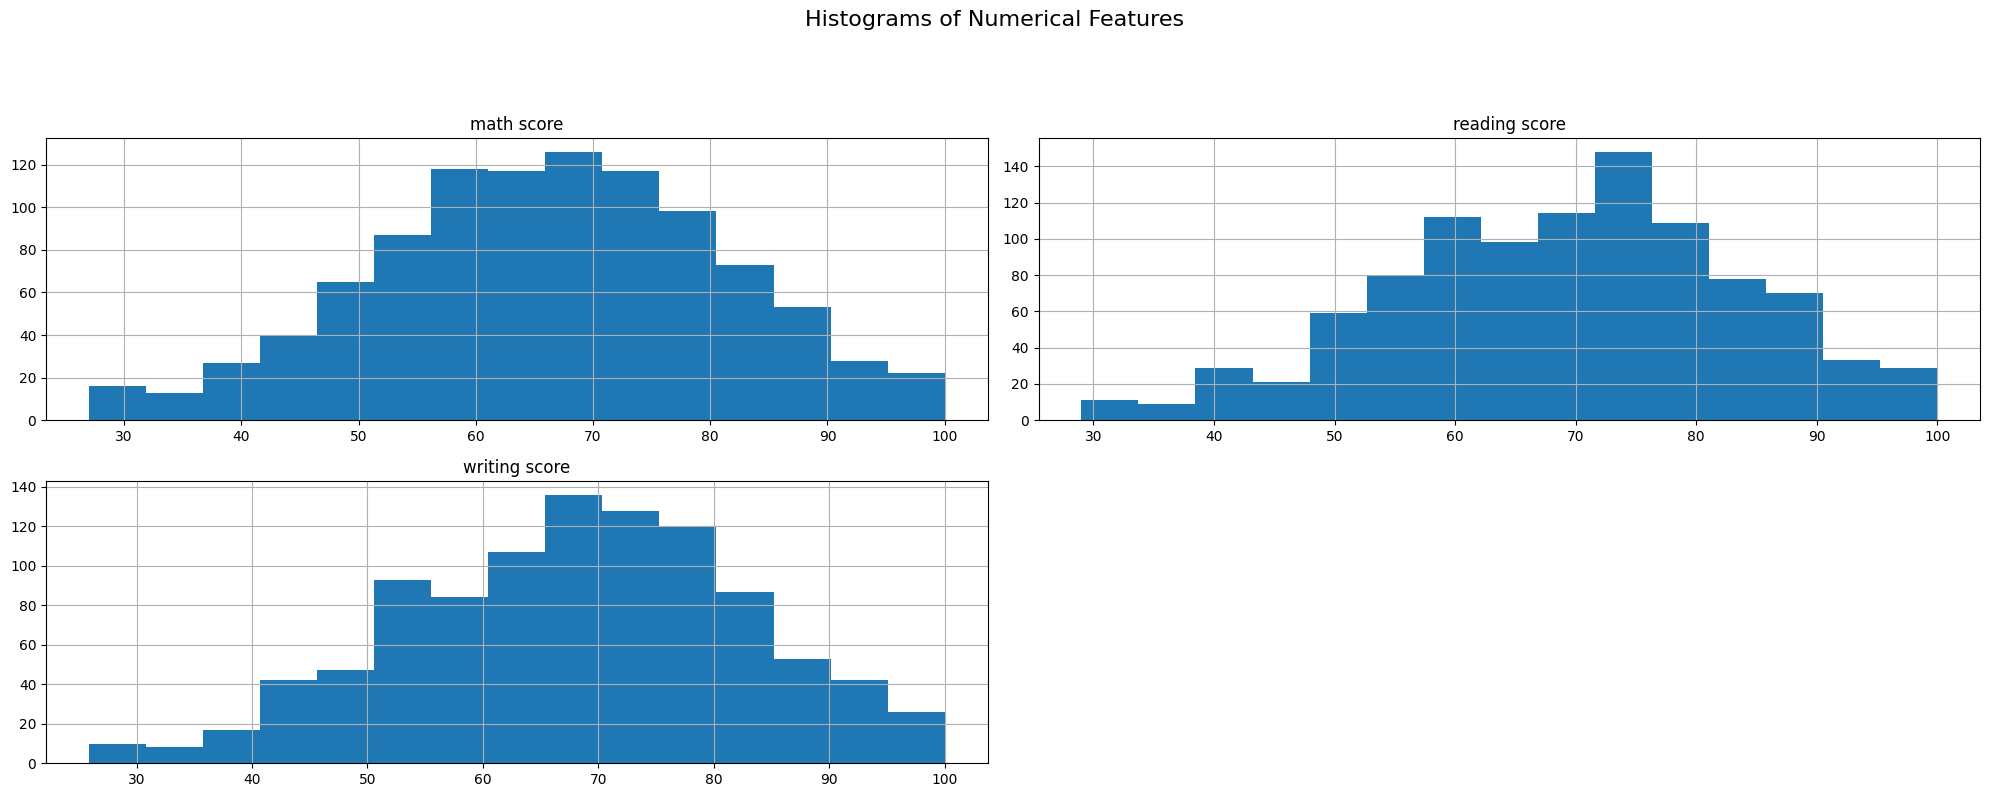

In [ ]:
# --- Histograms for Numerical Features ---
df[numerical_cols].hist(figsize=(20, 8), bins=15)
plt.suptitle('Histograms of Numerical Features', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Histograms illustrate the distribution of numerical scores, showing most scores are in the middle range.

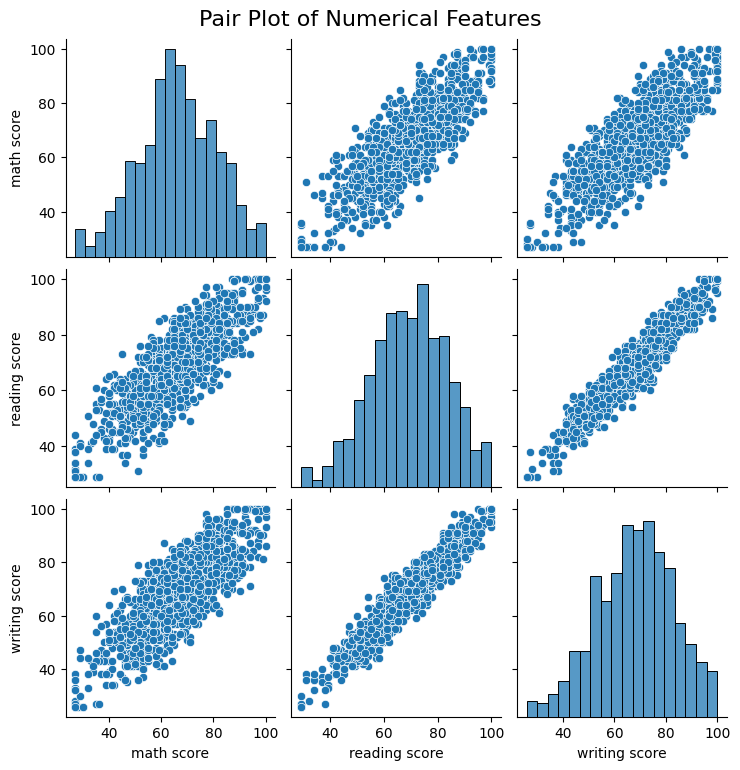

In [ ]:
# --- Pairplot (Scatter plots for numerical features and histograms) ---
sns.pairplot(df[numerical_cols])
plt.suptitle('Pair Plot of Numerical Features', y=1.02, fontsize=16)
plt.show()

The pair plot visualizes relationships between numerical features and their distributions.

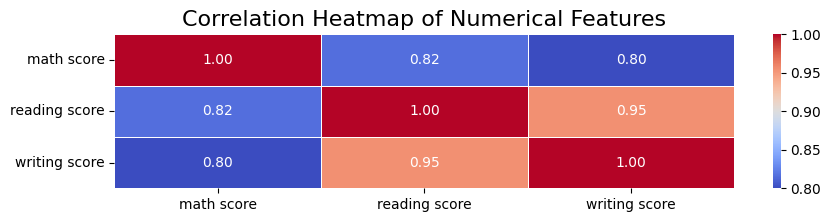

In [ ]:
# --- Correlation Heatmap for Numerical Features ---
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10 , 2))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

This heatmap shows strong positive correlations among math, reading, and writing scores.

In [ ]:
# --- Label Encoding for Categorical Features ---
df_label_encoded = df.copy() # Create a copy to store label encoded features
for col in categorical_cols: df_label_encoded[col] = LabelEncoder().fit_transform(df_label_encoded[col])

In [ ]:
# Drop 'parental level of education' as it has the lowest correlation with 'math score'
df_label_encoded = df_label_encoded.drop(columns=['parental level of education'])

In [ ]:
# --- One-Hot Encoding for Categorical Features ---
df_one_hot_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

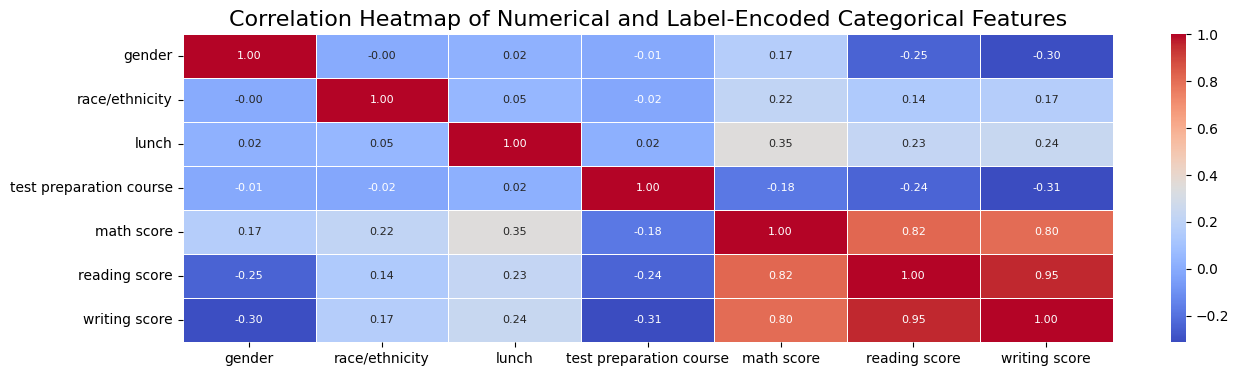

In [ ]:
corr_matrix_all = df_label_encoded.corr()

plt.figure(figsize=(15 , 4))
sns.heatmap(corr_matrix_all, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 8})
plt.title('Correlation Heatmap of Numerical and Label-Encoded Categorical Features', fontsize=16)
plt.show()

This heatmap displays correlations between all features, including label-encoded categorical ones, and the target variable.

### **Data Preprocessing:**

In [ ]:
# Define target variable (y) and features (X)
y = df_label_encoded['math score']
X = df_label_encoded.drop('math score', axis=1)

display(f"X shape: {X.shape}")
display(f"y shape: {y.shape}")

'X shape: (1000, 6)'

'y shape: (1000,)'

### **Feature Selection:**

In [ ]:
# Calculate absolute correlations with the target variable
correlations = X.corrwith(y).abs().sort_values(ascending=False)

# Select features with correlation > 0.05 (threshold can be adjusted)
selected_features = correlations[correlations > 0.05].index.tolist()
X_selected = X[selected_features]

display(f"Selected features: {selected_features}")
display(f"X_selected shape: {X_selected.shape}")

"Selected features: ['reading score', 'writing score', 'lunch', 'race/ethnicity', 'test preparation course', 'gender']"

'X_selected shape: (1000, 6)'

### **Train-Test Split:**

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

### **Feature Scaling:**

In [ ]:
# Initialize and apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

display(f"X_train_scaled shape: {X_train_scaled.shape}")
display(f"X_test_scaled shape: {X_test_scaled.shape}")

'X_train_scaled shape: (800, 6)'

'X_test_scaled shape: (200, 6)'

### **Model Training:**

In [ ]:
# Initialize the Random Forest Regressor model
model = RandomForestRegressor(random_state=42)

In [ ]:
# Train the model
model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

### **Model Evaluation:**

In [ ]:
# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

display(f"R-squared (R2 Score): {r2:.4f}")
display(f"Mean Absolute Error (MAE): {mae:.4f}")

'R-squared (R2 Score): 0.8429'

'Mean Absolute Error (MAE): 4.5926'

### **Train vs Test Score Check:**

In [ ]:
# Predictions on training data
y_train_pred = model.predict(X_train_scaled)

# R2 score for training data
r2_train = r2_score(y_train, y_train_pred)

display(f"R-squared (R2 Score) on Training Data: {r2_train:.4f}")
display(f"R-squared (R2 Score) on Test Data: {r2:.4f}")

'R-squared (R2 Score) on Training Data: 0.9746'

'R-squared (R2 Score) on Test Data: 0.8429'

### **Hyperparameter Tuning (GridSearchCV):**

In [ ]:
# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None], # None means nodes are expanded until all leaves are pure
    'min_samples_split': [2, 5]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, scoring='r2')

# Fit GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train)

# Display the best parameters and best score
display(f"Best Parameters: {grid_search.best_params_}")
display(f"Best R2 Score from GridSearchCV: {grid_search.best_score_:.4f}")

# Store the best estimator
best_model = grid_search.best_estimator_

"Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}"

'Best R2 Score from GridSearchCV: 0.8340'

### **Cross-Validation:**

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation using the best model
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)

# Display the cross-validation scores and their mean
display(f"Cross-Validation R2 Scores: {cv_scores}")
display(f"Mean Cross-Validation R2 Score: {cv_scores.mean():.4f}")

'Cross-Validation R2 Scores: [0.85254745 0.85568779 0.81493667 0.83054503 0.83892302]'

'Mean Cross-Validation R2 Score: 0.8385'

### **Pipeline (Final Packaging):**

In [ ]:
# Create a pipeline with StandardScaler and the best Random Forest Regressor
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(**grid_search.best_params_, random_state=42))
])

### **Train and Evaluate Pipeline:**

In [ ]:
# Train the pipeline
pipeline.fit(X_train, y_train)

# Make predictions with the pipeline
pipeline_y_pred = pipeline.predict(X_test)

# Evaluate the pipeline's performance
pipeline_r2 = r2_score(y_test, pipeline_y_pred)
pipeline_mae = mean_absolute_error(y_test, pipeline_y_pred)

display(f"Pipeline R-squared (R2 Score): {pipeline_r2:.4f}")
display(f"Pipeline Mean Absolute Error (MAE): {pipeline_mae:.4f}")

'Pipeline R-squared (R2 Score): 0.8527'

'Pipeline Mean Absolute Error (MAE): 4.4599'

### **Feature Importance:**

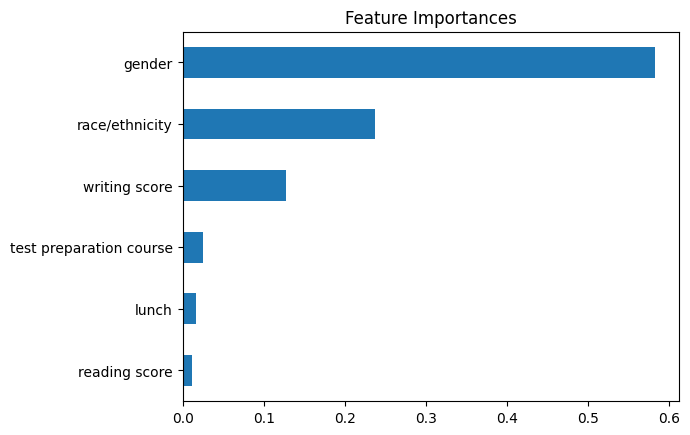

In [ ]:
importance = best_model.feature_importances_
feat_imp = pd.Series(importance, index=X.columns)
feat_imp.sort_values().plot(kind='barh')
plt.title('Feature Importances')
plt.show()

This bar chart highlights the most important features for predicting math scores.

### **Final Result:**

In [ ]:
results = pd.DataFrame({
    'Model': ['Random Forest Pipeline'],
    'R2 Score': [pipeline_r2],
    'MAE': [pipeline_mae],
    'Mean CV R2 Score': [cv_scores.mean()]
})

display(results)

,Model,R2 Score,MAE,Mean CV R2 Score
0,Random Forest Pipeline,0.852725,4.459904,0.838528


# **Conclusion:**

- The Random Forest Regressor performed well on the dataset with a strong R² score of 0.85.

- Hyperparameter tuning and pipeline implementation improved the overall model performance.

- Cross-validation results showed that the model is stable and generalizes well on unseen data.